In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load the monthly KSE 100 total return data from Stage 2
kse = pd.read_csv(
    r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\data\processed\kse_monthly_total_return.csv',
    index_col='Date', parse_dates=True
)

# Load the portfolio returns from Stage 3
portfolio_returns = pd.read_csv(
    r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\data\processed\portfolio_returns.csv',
    index_col='Date', parse_dates=True
)

print(f"Loaded KSE 100 data: {len(kse)} months ({kse.index[0].date()} to {kse.index[-1].date()})")
print(f"Loaded portfolio returns: {len(portfolio_returns)} months")
print(f"Risk tiers available: {list(portfolio_returns.columns)}")

Loaded KSE 100 data: 179 months (2010-02-28 to 2024-12-31)
Loaded portfolio returns: 179 months
Risk tiers available: ['Conservative', 'Moderate', 'Aggressive']


In [2]:
# SIP PARAMETERS
MONTHLY_INVESTMENT = 50000  # PKR per month
DEFAULT_TIER = 'Aggressive'

# Redefine risk tiers (they were defined in the Stage 3 notebook)
risk_tiers = {
    'Conservative': {
        'equity_pct': 0.60,
        'income_pct': 0.40,
        'description': "For investors who can't stomach big drawdowns."
    },
    'Moderate': {
        'equity_pct': 0.80,
        'income_pct': 0.20,
        'description': 'Balanced. Most of the upside, with a small cushion.'
    },
    'Aggressive': {
        'equity_pct': 1.00,
        'income_pct': 0.00,
        'description': 'For young investors with 10+ year horizons.'
    }
}

print(f"Monthly Investment: PKR {MONTHLY_INVESTMENT:,.0f}")
print(f"Default Risk Tier: {DEFAULT_TIER}")
print(f"  -> {risk_tiers[DEFAULT_TIER]['description']}")

Monthly Investment: PKR 50,000
Default Risk Tier: Aggressive
  -> For young investors with 10+ year horizons.


In [3]:
def run_sip_backtest(monthly_investment, returns_series, start_date=None, end_date=None):
    """
    Simulate a monthly SIP (Systematic Investment Plan).
    Each month: existing portfolio grows by the market return, then investor adds new money.
    """
    # Filter to date range if specified
    if start_date:
        returns_series = returns_series[returns_series.index >= start_date]
    if end_date:
        returns_series = returns_series[returns_series.index <= end_date]
    
    # Initialize DataFrame
    sip = pd.DataFrame(index=returns_series.index)
    sip['Monthly_Investment'] = monthly_investment
    sip['Cumulative_Invested'] = sip['Monthly_Investment'].cumsum()
    
    # Simulate month by month
    portfolio_value = 0
    portfolio_values = []
    
    for date, monthly_return in returns_series.items():
        # Step 1: Existing portfolio grows by this month's return
        portfolio_value = portfolio_value * (1 + monthly_return)
        # Step 2: Investor adds new money at end of month
        portfolio_value += monthly_investment
        portfolio_values.append(portfolio_value)
    
    sip['Portfolio_Value'] = portfolio_values
    sip['Profit_Loss'] = sip['Portfolio_Value'] - sip['Cumulative_Invested']
    sip['Return_on_Invested'] = sip['Profit_Loss'] / sip['Cumulative_Invested']
    
    return sip


# Run the backtest for the Aggressive tier
sip_aggressive = run_sip_backtest(
    monthly_investment=MONTHLY_INVESTMENT,
    returns_series=portfolio_returns[DEFAULT_TIER]
)

print("SIP Backtest Complete!")
print()
print(sip_aggressive.head(10))
print()
print("...")
print()
print(sip_aggressive.tail(10))

SIP Backtest Complete!

            Monthly_Investment  Cumulative_Invested  Portfolio_Value   Profit_Loss  Return_on_Invested
Date                                                                                                  
2010-02-28               50000                50000     50000.000000      0.000000            0.000000
2010-03-31               50000               100000    102940.330746   2940.330746            0.029403
2010-04-30               50000               150000    155952.130196   5952.130196            0.039681
2010-05-31               50000               200000    190094.920712  -9905.079288           -0.049525
2010-06-30               50000               250000    249074.251348   -925.748652           -0.003703
2010-07-31               50000               300000    320756.838654  20756.838654            0.069189
2010-08-31               50000               350000    350574.231530    574.231530            0.001641
2010-09-30               50000               4000

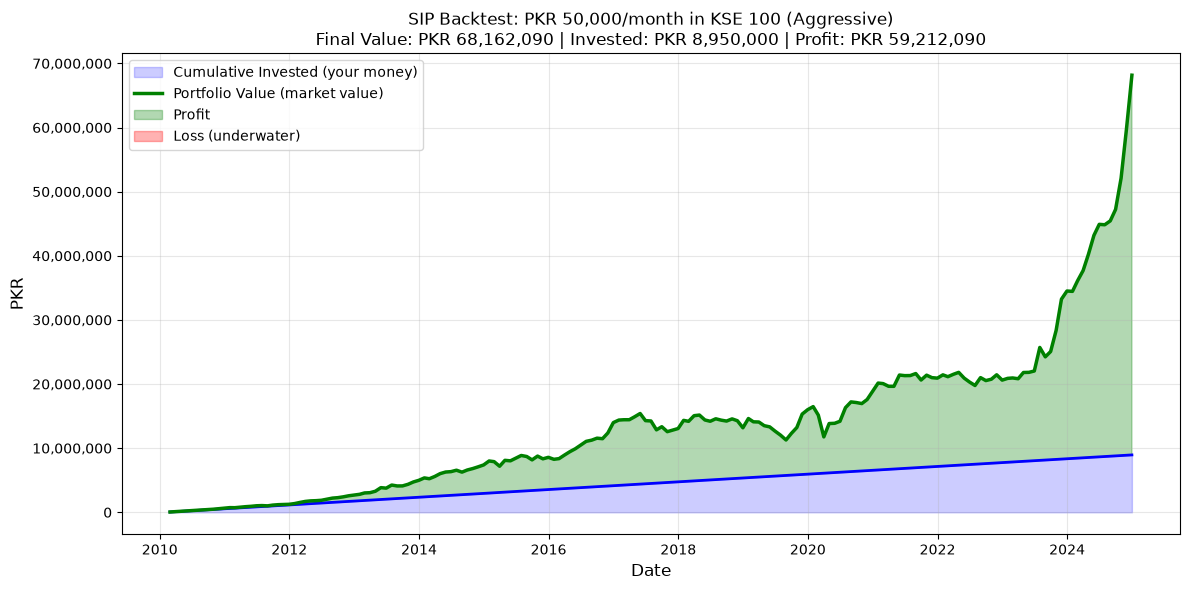

Chart saved to docs/sip_growth_aggressive.png

=== FINAL RESULTS (Aggressive Tier, PKR 50,000/month) ===
Total Invested:      PKR 8,950,000
Portfolio Value:     PKR 68,162,090
Profit/Loss:         PKR 59,212,090
Return on Invested:  661.6%


In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

# Cumulative invested (what the investor put in)
ax.fill_between(sip_aggressive.index, 0, sip_aggressive['Cumulative_Invested'],
                alpha=0.2, color='blue', label='Cumulative Invested (your money)')
ax.plot(sip_aggressive.index, sip_aggressive['Cumulative_Invested'],
        color='blue', linewidth=2)

# Portfolio value (what it's worth now)
ax.plot(sip_aggressive.index, sip_aggressive['Portfolio_Value'],
        color='green', linewidth=2.5, label='Portfolio Value (market value)')

# Profit area (green when above invested, red when below)
ax.fill_between(sip_aggressive.index, sip_aggressive['Cumulative_Invested'],
                sip_aggressive['Portfolio_Value'],
                where=(sip_aggressive['Portfolio_Value'] >= sip_aggressive['Cumulative_Invested']),
                alpha=0.3, color='green', label='Profit')
ax.fill_between(sip_aggressive.index, sip_aggressive['Cumulative_Invested'],
                sip_aggressive['Portfolio_Value'],
                where=(sip_aggressive['Portfolio_Value'] < sip_aggressive['Cumulative_Invested']),
                alpha=0.3, color='red', label='Loss (underwater)')

ax.set_title(f'SIP Backtest: PKR {MONTHLY_INVESTMENT:,.0f}/month in KSE 100 ({DEFAULT_TIER})\n'
             f'Final Value: PKR {sip_aggressive["Portfolio_Value"].iloc[-1]:,.0f} | '
             f'Invested: PKR {sip_aggressive["Cumulative_Invested"].iloc[-1]:,.0f} | '
             f'Profit: PKR {sip_aggressive["Profit_Loss"].iloc[-1]:,.0f}',
             fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('PKR', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\docs\sip_growth_aggressive.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart saved to docs/sip_growth_aggressive.png")
print()
print(f"=== FINAL RESULTS (Aggressive Tier, PKR {MONTHLY_INVESTMENT:,.0f}/month) ===")
print(f"Total Invested:      PKR {sip_aggressive['Cumulative_Invested'].iloc[-1]:,.0f}")
print(f"Portfolio Value:     PKR {sip_aggressive['Portfolio_Value'].iloc[-1]:,.0f}")
print(f"Profit/Loss:         PKR {sip_aggressive['Profit_Loss'].iloc[-1]:,.0f}")
print(f"Return on Invested:  {sip_aggressive['Return_on_Invested'].iloc[-1]*100:.1f}%")

In [5]:
sip_results = {}

for tier_name in risk_tiers.keys():
    sip_results[tier_name] = run_sip_backtest(
        monthly_investment=MONTHLY_INVESTMENT,
        returns_series=portfolio_returns[tier_name]
    )

print(f"=== SIP COMPARISON: PKR {MONTHLY_INVESTMENT:,.0f}/month over {len(sip_aggressive)} months ===\n")
print(f"{'Tier':<15} {'Invested':>15} {'Value':>15} {'Profit':>15} {'Return':>10}")
print("-" * 75)
for tier_name, sip in sip_results.items():
    invested = sip['Cumulative_Invested'].iloc[-1]
    value = sip['Portfolio_Value'].iloc[-1]
    profit = sip['Profit_Loss'].iloc[-1]
    ret = sip['Return_on_Invested'].iloc[-1] * 100
    print(f"{tier_name:<15} {invested:>15,.0f} {value:>15,.0f} {profit:>15,.0f} {ret:>9.1f}%")

=== SIP COMPARISON: PKR 50,000/month over 179 months ===

Tier                   Invested           Value          Profit     Return
---------------------------------------------------------------------------
Conservative          8,950,000      40,197,471      31,247,471     349.1%
Moderate              8,950,000      52,585,080      43,635,080     487.5%
Aggressive            8,950,000      68,162,090      59,212,090     661.6%


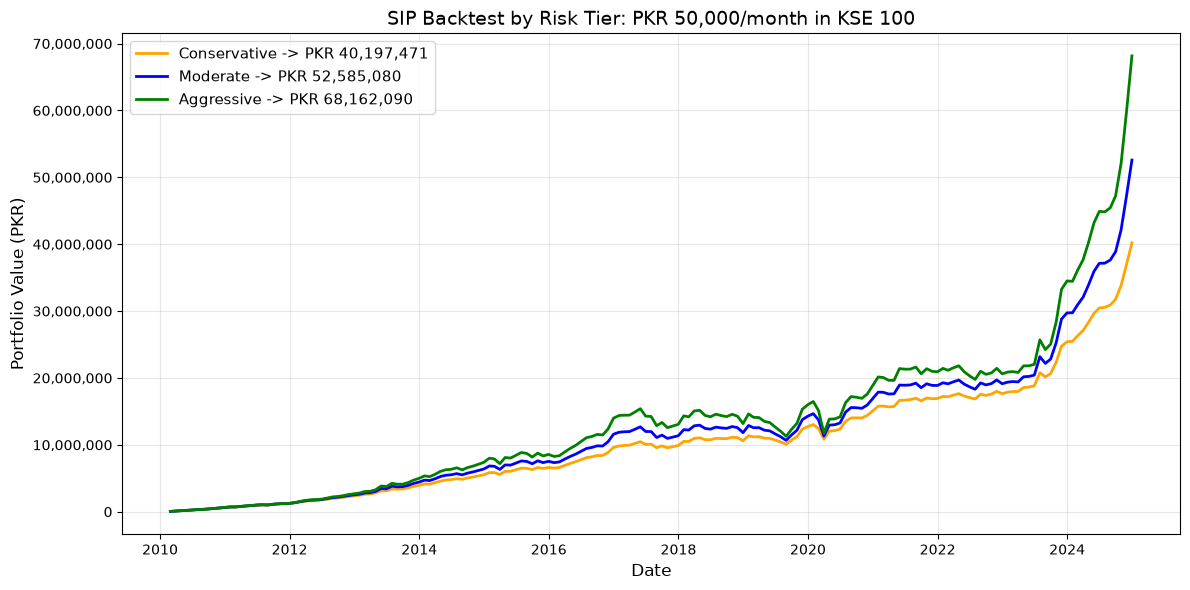

Chart saved to docs/sip_growth_by_tier.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'Conservative': 'orange', 'Moderate': 'blue', 'Aggressive': 'green'}

for tier_name, sip in sip_results.items():
    ax.plot(sip.index, sip['Portfolio_Value'],
            label=f"{tier_name} -> PKR {sip['Portfolio_Value'].iloc[-1]:,.0f}",
            color=colors[tier_name], linewidth=2)

ax.set_title(f'SIP Backtest by Risk Tier: PKR {MONTHLY_INVESTMENT:,.0f}/month in KSE 100', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Portfolio Value (PKR)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\docs\sip_growth_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to docs/sip_growth_by_tier.png")

In [7]:
# Find the worst peak-to-trough drawdown in KSE 100 history
running_max = kse['TR_Index'].cummax()
drawdown = (kse['TR_Index'] - running_max) / running_max
worst_trough_date = drawdown.idxmin()
worst_drawdown_pct = drawdown.min()

# Find the peak date before the trough
peak_mask = kse['TR_Index'] == running_max.loc[worst_trough_date]
peak_date = kse.index[peak_mask][0]

print(f"Worst drawdown in KSE 100 history:")
print(f"  Peak date (worst time to start): {peak_date.date()}")
print(f"  Trough date:                      {worst_trough_date.date()}")
print(f"  Drawdown:                         {worst_drawdown_pct*100:.1f}%")
print()

# Run SIP starting from the worst peak
months_after_peak = len(kse[kse.index > peak_date])
print(f"Months available after peak: {months_after_peak}")
print()

if months_after_peak >= 36:
    sip_worst_start = run_sip_backtest(
        monthly_investment=MONTHLY_INVESTMENT,
        returns_series=portfolio_returns[DEFAULT_TIER],
        start_date=peak_date
    )
    
    print("Worst-start SIP Backtest Complete!")
    print()
    print(f"Started at peak: {peak_date.date()}")
    print(f"Total Invested:  PKR {sip_worst_start['Cumulative_Invested'].iloc[-1]:,.0f}")
    print(f"Portfolio Value: PKR {sip_worst_start['Portfolio_Value'].iloc[-1]:,.0f}")
    print(f"Profit/Loss:    PKR {sip_worst_start['Profit_Loss'].iloc[-1]:,.0f}")
    print(f"Return:          {sip_worst_start['Return_on_Invested'].iloc[-1]*100:.1f}%")
else:
    print("Not enough months after peak for a meaningful comparison.")

Worst drawdown in KSE 100 history:
  Peak date (worst time to start): 2017-05-31
  Trough date:                      2019-08-31
  Drawdown:                         -31.4%

Months available after peak: 91

Worst-start SIP Backtest Complete!

Started at peak: 2017-05-31
Total Invested:  PKR 4,600,000
Portfolio Value: PKR 15,128,894
Profit/Loss:    PKR 10,528,894
Return:          228.9%


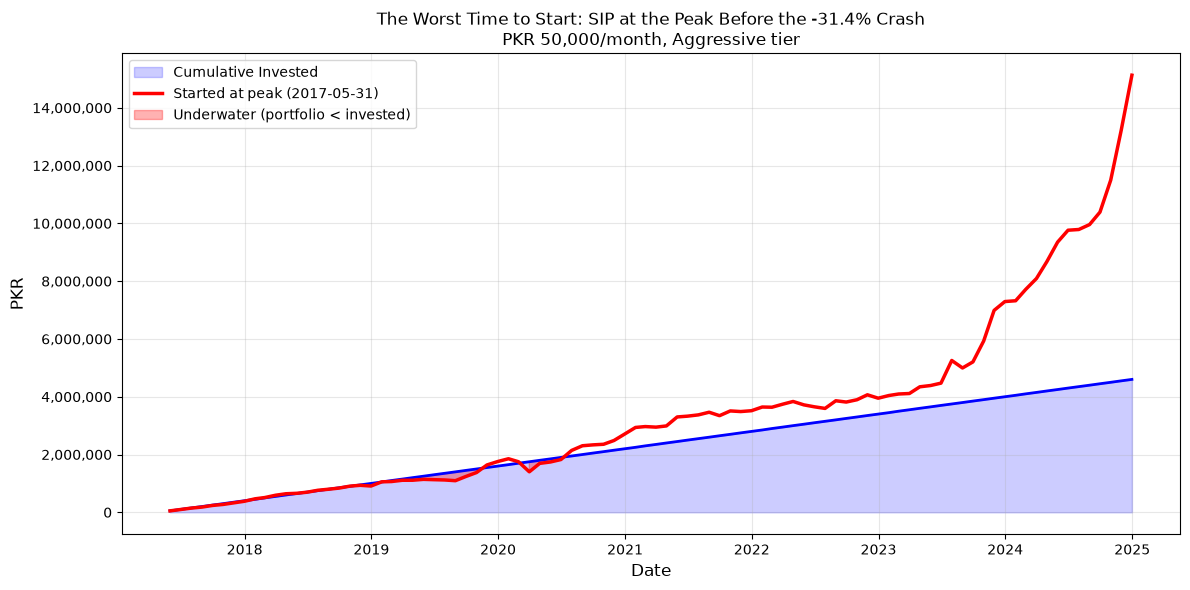

Chart saved to docs/sip_worst_start.png

KEY INSIGHT: Even starting at the worst possible time (right before a major crash),
rupee-cost averaging allowed the investor to recover and eventually profit.
This is the power of DCA — it smooths out bad timing.


In [8]:
if months_after_peak >= 36:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Cumulative invested
    ax.fill_between(sip_worst_start.index, 0, sip_worst_start['Cumulative_Invested'],
                    alpha=0.2, color='blue', label='Cumulative Invested')
    ax.plot(sip_worst_start.index, sip_worst_start['Cumulative_Invested'],
            color='blue', linewidth=2)
    
    # Portfolio value (started at peak)
    ax.plot(sip_worst_start.index, sip_worst_start['Portfolio_Value'],
            color='red', linewidth=2.5, label=f'Started at peak ({peak_date.date()})')
    
    # Underwater area
    ax.fill_between(sip_worst_start.index, sip_worst_start['Cumulative_Invested'],
                    sip_worst_start['Portfolio_Value'],
                    where=(sip_worst_start['Portfolio_Value'] < sip_worst_start['Cumulative_Invested']),
                    alpha=0.3, color='red', label='Underwater (portfolio < invested)')
    
    ax.set_title(f'The Worst Time to Start: SIP at the Peak Before the {worst_drawdown_pct*100:.1f}% Crash\n'
                 f'PKR {MONTHLY_INVESTMENT:,.0f}/month, {DEFAULT_TIER} tier',
                 fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('PKR', fontsize=12)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    
    plt.tight_layout()
    plt.savefig(r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\docs\sip_worst_start.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Chart saved to docs/sip_worst_start.png")
    print()
    print("KEY INSIGHT: Even starting at the worst possible time (right before a major crash),")
    print("rupee-cost averaging allowed the investor to recover and eventually profit.")
    print("This is the power of DCA — it smooths out bad timing.")

In [9]:
# Save the aggressive SIP results
sip_aggressive.to_csv(
    r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\data\processed\sip_aggressive.csv'
)

# Save the worst-start SIP results if they exist
if months_after_peak >= 36:
    sip_worst_start.to_csv(
        r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\data\processed\sip_worst_start.csv'
    )

print("Results saved to data/processed/")
print(f"  - sip_aggressive.csv ({len(sip_aggressive)} rows)")
if months_after_peak >= 36:
    print(f"  - sip_worst_start.csv ({len(sip_worst_start)} rows)")

Results saved to data/processed/
  - sip_aggressive.csv (179 rows)
  - sip_worst_start.csv (92 rows)
